# B3 - Training dynamics: the things that actually decide success

The mechanics in B2 are easy. The *dynamics* are what make AlphaZero hard - and
they're exactly what raccoon's experiments wrestle with. Here we reproduce three of
them on tic-tac-toe, where each run takes seconds.

In [1]:
import numpy as np, torch
import matplotlib.pyplot as plt
from azl.games.tictactoe import TicTacToe
from azl.network import net_for_game
from azl.trainer import Coach, CoachConfig
from azl.solvers import ExactSolver, enumerate_states
from azl.evaluate import mcts_player
from azl.metrics import optimal_action_accuracy, visit_entropy, effective_moves
from azl.mcts import MCTS, select_action

solver = ExactSolver()
states = enumerate_states(TicTacToe.start())
grade = [states[i] for i in np.random.default_rng(0).choice(len(states), 200, replace=False)]

## 1. More simulations -> better policy targets
The single most important knob in raccoon's experiments. With more MCTS sims per
move, the visit distribution is a *better* teacher, so the policy head learns faster.
We train short runs at a few simulation budgets and grade each.

sims=  8: optimal-move accuracy after 10 iters = 0.805


sims= 24: optimal-move accuracy after 10 iters = 0.945


sims= 64: optimal-move accuracy after 10 iters = 0.970


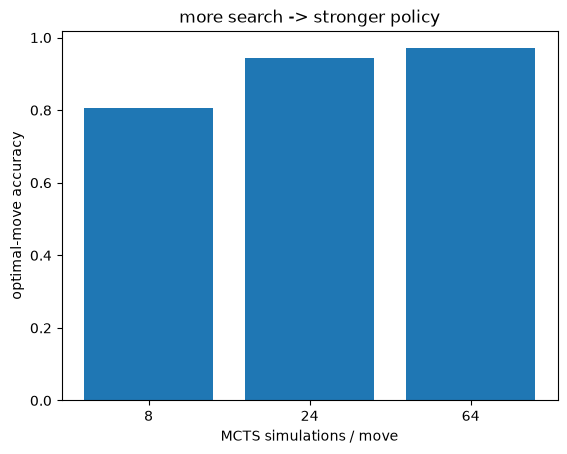

In [2]:
result = {}
for sims in [8, 24, 64]:
    torch.manual_seed(0)
    coach = Coach(net=net_for_game(TicTacToe), game_cls=TicTacToe,
                  config=CoachConfig(games_per_iter=16, num_simulations=sims, temp_threshold=3, training_steps=40),
                  seed=0)
    coach.train(10, verbose=False)
    play = mcts_player(coach.net, num_simulations=sims, rng=np.random.default_rng(1))
    result[sims] = optimal_action_accuracy(play, grade, solver)
    print(f"sims={sims:>3}: optimal-move accuracy after 10 iters = {result[sims]:.3f}")

plt.bar([str(k) for k in result], list(result.values()))
plt.xlabel("MCTS simulations / move"); plt.ylabel("optimal-move accuracy"); plt.title("more search -> stronger policy"); plt.show()

## 2. Exploration health: visit entropy
`visit_entropy` measures how spread-out the search is; `exp(entropy)` is the
"effective number of moves" being considered. When it **collapses toward 0**, the
search keeps re-confirming a few moves and stops discovering alternatives - raccoon's
*plateau / exploration collapse*. Let's watch entropy over a training run.

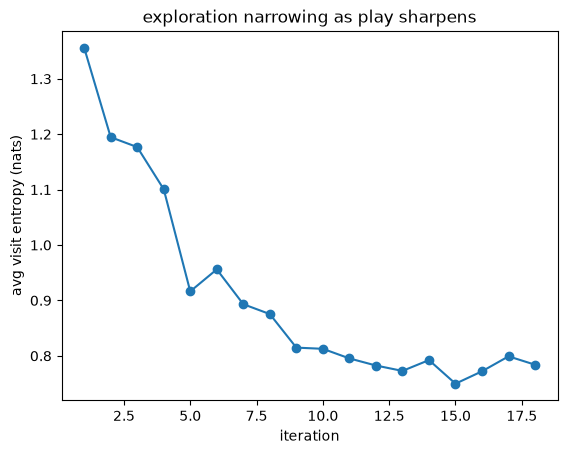

In [3]:
torch.manual_seed(0)
coach = Coach(net=net_for_game(TicTacToe), game_cls=TicTacToe,
              config=CoachConfig(games_per_iter=16, num_simulations=48, temp_threshold=3), seed=0)
coach.train(18, verbose=False)
ent = [h["avg_visit_entropy"] for h in coach.history]
plt.plot([h["iteration"] for h in coach.history], ent, "o-")
plt.xlabel("iteration"); plt.ylabel("avg visit entropy (nats)"); plt.title("exploration narrowing as play sharpens"); plt.show()

## 3. Dirichlet noise and temperature - the exploration controls
**Dirichlet noise** mixed into the root prior forces the search to occasionally try
moves the net underrates (raccoon's `dirichlet_alpha`). **Temperature** controls how
greedily we sample the final move from visit counts.

In [4]:
# Dirichlet noise is added to the ROOT PRIOR, so it only matters when the net is
# *opinionated*. We reuse the trained net from section 2 at a position where it has
# clear (non-uniform) opinions and watch noise flatten that prior - the whole point:
# occasionally try moves the net underrates, so self-play stays diverse.
s = TicTacToe(board=(1, 1, 0, 2, 2, 0, 0, 0, 0), player=0)
prior, _ = coach.net.predict(s.encode(), s.legal_actions())
print("trained net's raw prior:", {a: round(p, 2) for a, p in prior.items()})
print("  raw prior entropy:", round(visit_entropy(prior), 2), "nats\n")

acts = list(prior); base = np.array([prior[a] for a in acts])
for alpha in [1.0, 0.3]:
    noise = np.random.default_rng(0).dirichlet([alpha] * len(acts))
    noisy = 0.75 * base + 0.25 * noise          # noise_eps = 0.25, like raccoon
    noisy_dict = {a: float(p) for a, p in zip(acts, noisy)}
    print(f"+ Dirichlet(alpha={alpha}): noisy prior entropy = {round(visit_entropy(noisy_dict), 2)} nats")
print("-> noise raises the prior's entropy, nudging search toward under-explored moves.\n")

# Temperature controls how greedily the FINAL move is sampled from visit counts.
visit_counts = {0: 50, 4: 30, 2: 12, 6: 8}     # a pretend root distribution
for temp in [0.0, 0.5, 1.0, 2.0]:
    picks = [select_action(visit_counts, temperature=temp, rng=np.random.default_rng(k)) for k in range(200)]
    frac = {a: round(picks.count(a) / 200, 2) for a in visit_counts}
    print(f"temperature={temp}: P(pick) = {frac}")

trained net's raw prior: {2: 0.17, 5: 0.48, 6: 0.2, 7: 0.12, 8: 0.03}
  raw prior entropy: 1.32 nats

+ Dirichlet(alpha=1.0): noisy prior entropy = 1.38 nats
+ Dirichlet(alpha=0.3): noisy prior entropy = 1.45 nats
-> noise raises the prior's entropy, nudging search toward under-explored moves.

temperature=0.0: P(pick) = {0: 1.0, 4: 0.0, 2: 0.0, 6: 0.0}
temperature=0.5: P(pick) = {0: 0.63, 4: 0.28, 2: 0.07, 6: 0.02}
temperature=1.0: P(pick) = {0: 0.41, 4: 0.33, 2: 0.14, 6: 0.12}
temperature=2.0: P(pick) = {0: 0.3, 4: 0.29, 2: 0.2, 6: 0.2}


### Maps to raccoon
These three plots are the toy versions of raccoon's `training_analysis` and
`mcts_explained` findings: *more sims helped* (exp005), *Dirichlet noise alone
didn't break the plateau*, and *visit entropy is the exploration-health gauge*. The
value of the toy is that you can run a controlled sweep in seconds instead of GPU-hours.